# Econ 390: Lecture 23 - Difference in Differences
Today we will be going over how to visualize and conduct the econometric method called Difference in Differences (DiD). DiD at its core is very simple, there is a point in time where something changes and we want to understand what that change caused. We can't just assume everything after the change is due to the change alone, so we find a comparison group to disentangle the change and time itself. Inspiration for this lecture can be found [here](https://www.pymc.io/projects/examples/en/latest/causal_inference/difference_in_differences.html) and [here](https://aaronmams.github.io/Card-Krueger-Replication/).

![Simple Diff-in-Diff Example](https://www.pymc.io/projects/examples/en/latest/_images/8f0282bc3fafdc3f95d353ed712496d5fab4d0c009f5c0d8ecaf42f7a8626b37.png)

## Parallel Trends
Parallel trends are *paramount* to our assumption of Difference-in-Differences analysis! It must be the case that these two groups are **actually comparable**. This analysis is all about what would have happened if the treatment group was not treated. We must be confident that we can actually extract that using the information on the control group!

## Card and Krueger (1994)
One of the most famous example of DiD is from the 1994 American Economic Review (AER) paper "Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania" by David Card and Alan Krueger (you can find the paper and data on Card's website [here](https://davidcard.berkeley.edu/data_sets)).

In [36]:
import pandas as pd
import matplotlib.pyplot as plt 
import statsmodels.formula.api as smf 

econ390path = "https://m-mcmain.github.io/files/Econ390SP26/"

In [37]:
# Data process
names = ["CHAINr", "CO_OWNED", "STATEr", "SOUTHJ", "CENTRALJ", "NORTHJ", "PA1", "PA2", "SHORE", "NCALLS", 
         "EMPFT", "EMPPT", "NMGRS", "WAGE_ST", "INCTIME", "FIRSTINC", "BONUS", "PCTAFF", "MEAL", "OPEN",
         "HRSOPEN", "PSODA", "PFRY", "PENTREE", "NREGS", "NREGS11", "TYPE2", "STATUS2", "DATE2", "NCALLS2",
         "EMPFT2", "EMPPT2", "NMGRS2", "WAGE_ST2", "INCTIME2", "FIRSTIN2", "SPECIAL2", "MEALS2", "OPEN2R",
         "HRSOPEN2", "PSODA2", "PFRY2", "PENTREE2", "NREGS2", "NREGS112"]
ck = pd.read_csv(econ390path + "card_krueger_public.dat", sep="\s+", header= None, names = names)
ck.head()

,CHAINr,CO_OWNED,STATEr,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,NCALLS,...,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
46,1,0,0,0,0,0,1,0,0,0,...,0.08,1,2,6.50,16.50,1.03,.,0.94,4,4
49,2,0,0,0,0,0,1,0,0,0,...,0.05,0,2,10.00,13.00,1.01,0.89,2.35,4,4
506,2,1,0,0,0,0,1,0,0,0,...,0.25,.,1,11.00,11.00,0.95,0.74,2.33,4,3
56,4,1,0,0,0,0,1,0,0,0,...,0.15,0,2,10.00,12.00,0.92,0.79,0.87,2,2
61,4,1,0,0,0,0,1,0,0,0,...,0.15,0,2,10.00,12.00,1.01,0.84,0.95,2,2


In [38]:
# Measure of employment
ck["EMP_TOT"] = pd.to_numeric(ck["EMPFT"], errors="coerce") + pd.to_numeric(ck["EMPPT"],errors="coerce")*0.5 + pd.to_numeric(ck["NMGRS"],errors="coerce")
ck["EMP_TOT2"] = pd.to_numeric(ck["EMPFT2"], errors="coerce") + pd.to_numeric(ck["EMPPT2"],errors="coerce")*0.5 + pd.to_numeric(ck["NMGRS2"],errors="coerce")
ck.head()

,CHAINr,CO_OWNED,STATEr,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,NCALLS,...,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112,EMP_TOT,EMP_TOT2
46,1,0,0,0,0,0,1,0,0,0,...,2,6.50,16.50,1.03,.,0.94,4,4,40.50,24.0
49,2,0,0,0,0,0,1,0,0,0,...,2,10.00,13.00,1.01,0.89,2.35,4,4,13.75,11.5
506,2,1,0,0,0,0,1,0,0,0,...,1,11.00,11.00,0.95,0.74,2.33,4,3,8.50,10.5
56,4,1,0,0,0,0,1,0,0,0,...,2,10.00,12.00,0.92,0.79,0.87,2,2,34.00,20.0
61,4,1,0,0,0,0,1,0,0,0,...,2,10.00,12.00,1.01,0.84,0.95,2,2,24.00,35.5


In [39]:
# Convert data we need
ck["WAGE_ST"] = pd.to_numeric(ck["WAGE_ST"],errors="coerce")
ck["WAGE_ST2"] = pd.to_numeric(ck["WAGE_ST2"],errors="coerce")
ck["STATEr"] = pd.Categorical.from_codes(ck["STATEr"], ["PA", "NJ"])

## Wage Visualizations

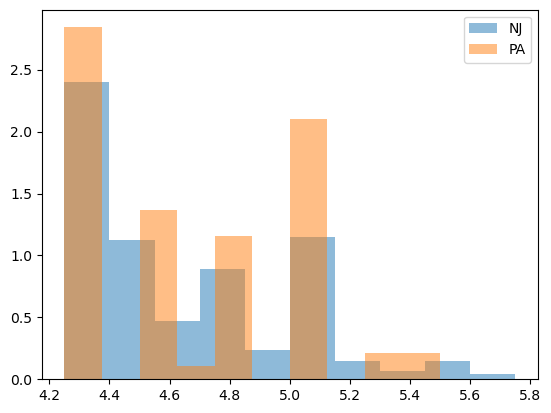

In [11]:
# Basic Visualization of Wages
plt.hist(ck["WAGE_ST"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="NJ")
plt.hist(ck["WAGE_ST"][ck["STATEr"]=="PA"], density=True, alpha=0.5, label="PA")
plt.legend(loc='upper right')
plt.show()

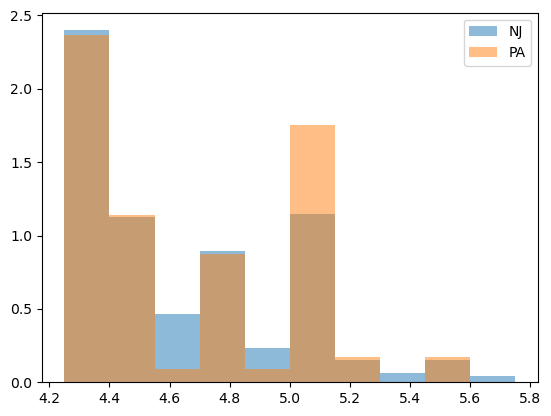

In [10]:
# Force the Same Bins
count, hist1_bins, patches = plt.hist(ck["WAGE_ST"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="NJ")
plt.hist(ck["WAGE_ST"][ck["STATEr"]=="PA"], bins=hist1_bins, density=True, alpha=0.5, label="PA")
plt.legend(loc='upper right')
plt.show()

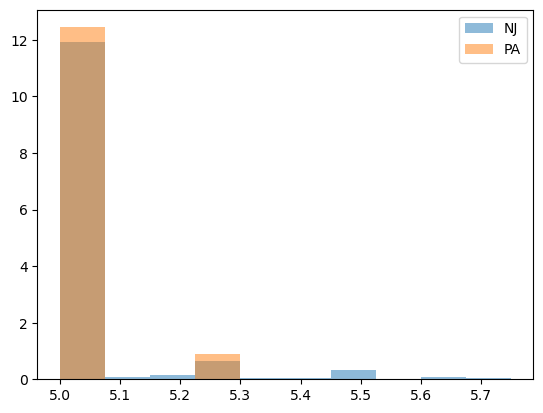

In [12]:
# Second Period same bins
count, hist1_bins, patches = plt.hist(ck["WAGE_ST2"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="NJ")
plt.hist(ck["WAGE_ST2"][ck["STATEr"]=="PA"], bins=hist1_bins, density=True, alpha=0.5, label="PA")
plt.legend(loc='upper right')
plt.show()

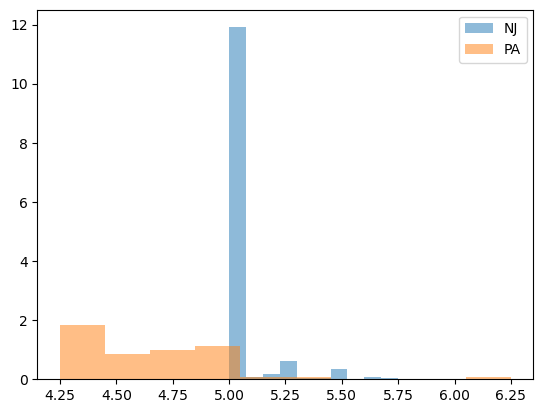

In [13]:
# Good reason to not have the same bins!
plt.hist(ck["WAGE_ST2"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="NJ")
plt.hist(ck["WAGE_ST2"][ck["STATEr"]=="PA"], density=True, alpha=0.5, label="PA")
plt.legend(loc='upper right')
plt.show()

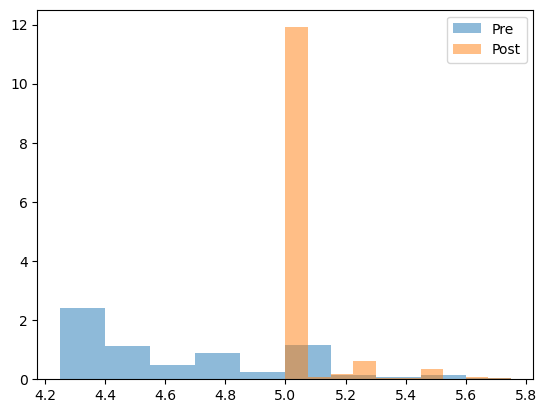

In [15]:
# Compare within NJ before and after
plt.hist(ck["WAGE_ST"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="Pre")
plt.hist(ck["WAGE_ST2"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="Post")
plt.legend(loc='upper right')
plt.show()

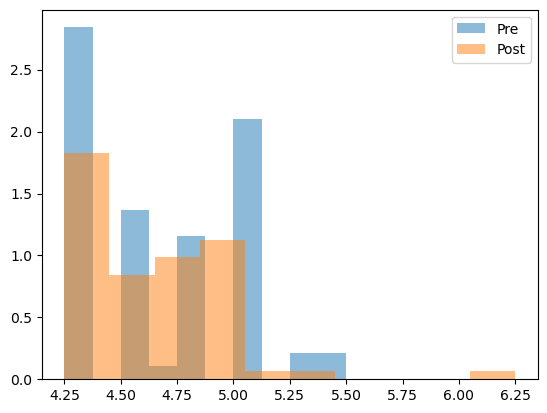

In [16]:
# What happens in PA?
plt.hist(ck["WAGE_ST"][ck["STATEr"]=="PA"], density=True, alpha=0.5, label="Pre")
plt.hist(ck["WAGE_ST2"][ck["STATEr"]=="PA"], density=True, alpha=0.5, label="Post")
plt.legend(loc='upper right')
plt.show()

In [18]:
# Classic DiD Plot on Wage:
wage_before = ck[["STATEr","WAGE_ST"]].groupby("STATEr").mean()
wage_after = ck[["STATEr","WAGE_ST2"]].groupby("STATEr").mean()
avg_wage_df = pd.DataFrame({"Time":[0,1],
                            "Wage_NJ":[wage_before.iloc[1,0], wage_after.iloc[1,0]],
                            "Wage_PA":[wage_before.iloc[0,0], wage_after.iloc[0,0]]})
print(avg_wage_df)                            

   Time   Wage_NJ   Wage_PA
0     0  4.612134  4.630132
1     1  5.080849  4.617465


C:\Users\micha\AppData\Local\Temp\ipykernel_19640\3819204349.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wage_before = ck[["STATEr","WAGE_ST"]].groupby("STATEr").mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_19640\3819204349.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wage_after = ck[["STATEr","WAGE_ST2"]].groupby("STATEr").mean()


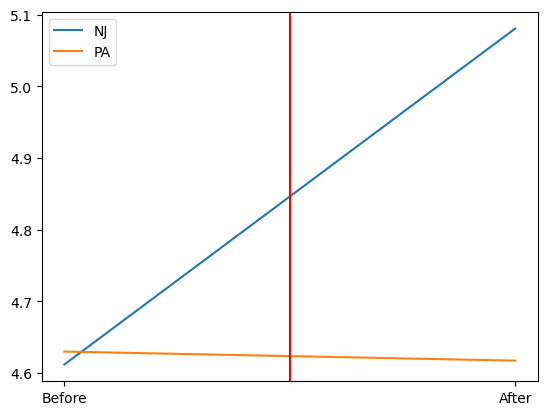

In [19]:
# Standard Plot, not necessarily surprising results
fig, ax = plt.subplots()
plt.plot(avg_wage_df["Time"],avg_wage_df["Wage_NJ"],label="NJ")
plt.plot(avg_wage_df["Time"],avg_wage_df["Wage_PA"],label="PA")
plt.axvline(0.5, color="red")
plt.legend()
labels=["Before","After"]
plt.xticks(avg_wage_df["Time"],labels)
plt.show()

## Employment Visualization

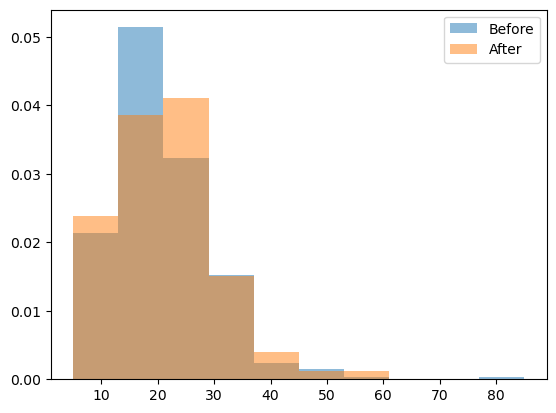

In [20]:
# Eployment Across Time in NJ
count, hist1_bins, patches = plt.hist(ck["EMP_TOT"][ck["STATEr"]=="NJ"], density=True, alpha=0.5, label="Before")
plt.hist(ck["EMP_TOT2"][ck["STATEr"]=="NJ"], bins=hist1_bins, density=True, alpha=0.5, label="After")
plt.legend(loc='upper right')
plt.show()

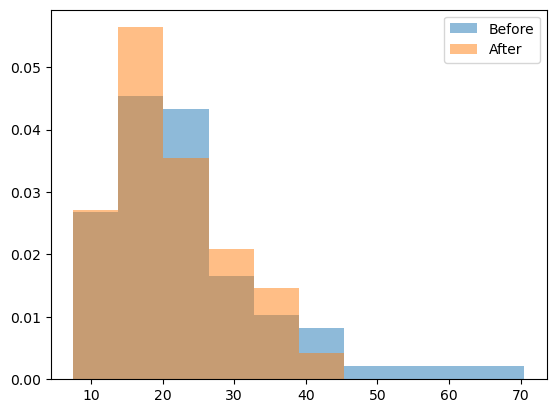

In [21]:
# Employment Across Time in PA
count, hist1_bins, patches = plt.hist(ck["EMP_TOT"][ck["STATEr"]=="PA"], density=True, alpha=0.5, label="Before")
plt.hist(ck["EMP_TOT2"][ck["STATEr"]=="PA"], bins=hist1_bins, density=True, alpha=0.5, label="After")
plt.legend(loc='upper right')
plt.show()

In [22]:
# Classic DiD Plot on Employment:
# Classic DiD Plot on Wage:
EMP_before = ck[["STATEr","EMP_TOT"]].groupby("STATEr").mean()
EMP_after = ck[["STATEr","EMP_TOT2"]].groupby("STATEr").mean()
avg_EMP_df = pd.DataFrame({"Time":[0,1],
                            "EMP_NJ":[EMP_before.iloc[1,0], EMP_after.iloc[1,0]],
                            "EMP_PA":[EMP_before.iloc[0,0], EMP_after.iloc[0,0]]})
print(avg_EMP_df)                            

   Time     EMP_NJ     EMP_PA
0     0  20.439408  23.331169
1     1  21.027429  21.165584


C:\Users\micha\AppData\Local\Temp\ipykernel_19640\3758376572.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  EMP_before = ck[["STATEr","EMP_TOT"]].groupby("STATEr").mean()
C:\Users\micha\AppData\Local\Temp\ipykernel_19640\3758376572.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  EMP_after = ck[["STATEr","EMP_TOT2"]].groupby("STATEr").mean()


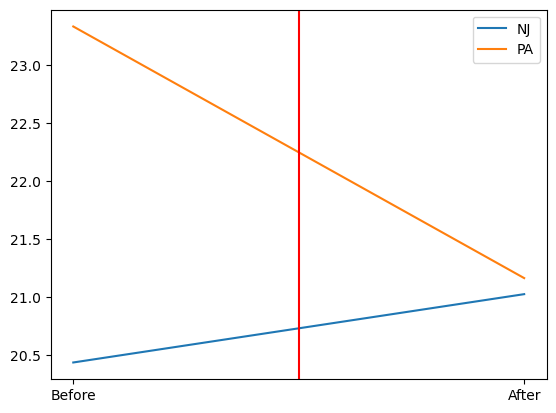

In [23]:
# Standard Plot, not necessarily surprising results
fig, ax = plt.subplots()
plt.plot(avg_EMP_df["Time"],avg_EMP_df["EMP_NJ"],label="NJ")
plt.plot(avg_EMP_df["Time"],avg_EMP_df["EMP_PA"],label="PA")
plt.axvline(0.5, color="red")
plt.legend()
labels=["Before","After"]
plt.xticks(avg_EMP_df["Time"],labels)
plt.show()

## DiD Regression

In [40]:
# Basic Regressions
ck["CHANGE_EMP"] =ck["EMP_TOT2"] - ck["EMP_TOT"]
model1 = smf.ols("CHANGE_EMP ~ STATEr",data=ck).fit(cov_type="HC1")
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             CHANGE_EMP   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     4.226
Date:                Tue, 21 Apr 2026   Prob (F-statistic):             0.0405
Time:                        15:34:40   Log-Likelihood:                -1386.2
No. Observations:                 384   AIC:                             2776.
Df Residuals:                     382   BIC:                             2784.
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -2.2833      1.248     -1.829   

The effect of the minimum wage increasing was that employment in New Jersey increased by 2.75 labor units on average **relative** to Pennsylvania

In [41]:
# More Elaborate Regressions
ck["CHAINr"] = pd.to_numeric(ck["CHAINr"],errors="coerce")-1
ck["CHAINr"] = pd.Categorical.from_codes(ck["CHAINr"],["Burger King", "KFC", "Roys", "Wendys"])
model2 = smf.ols("CHANGE_EMP ~ STATEr + CHAINr",data=ck).fit(cov_type="HC1")
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             CHANGE_EMP   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     3.290
Date:                Tue, 21 Apr 2026   Prob (F-statistic):             0.0114
Time:                        15:34:45   Log-Likelihood:                -1383.5
No. Observations:                 384   AIC:                             2777.
Df Residuals:                     379   BIC:                             2797.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.7659      1.501  

In [45]:
# This is kind of a non-standard way to do DiD
idvars = ["CHAINr", "STATEr", "CO_OWNED", "SOUTHJ", "CENTRALJ","NORTHJ","PA1","PA2","SHORE","NCALLS"]
allvars = idvars + ["EMP_TOT", "EMP_TOT2"]
ck_long = pd.melt(ck[allvars], id_vars = idvars,
                  var_name="Period", value_name = "EMP_TOTS")
ck_long["Period"] = pd.Categorical.from_codes(ck_long["Period"].replace(["EMP_TOT","EMP_TOT2"],[0,1]),["Before","After"])
ck_long

C:\Users\micha\AppData\Local\Temp\ipykernel_19640\2052397396.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ck_long["Period"] = pd.Categorical.from_codes(ck_long["Period"].replace(["EMP_TOT","EMP_TOT2"],[0,1]),["Before","After"])


,CHAINr,STATEr,CO_OWNED,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,NCALLS,Period,EMP_TOTS
0,Burger King,PA,0,0,0,0,1,0,0,0,Before,40.50
1,KFC,PA,0,0,0,0,1,0,0,0,Before,13.75
2,KFC,PA,1,0,0,0,1,0,0,0,Before,8.50
3,Wendys,PA,1,0,0,0,1,0,0,0,Before,34.00
4,Wendys,PA,1,0,0,0,1,0,0,0,Before,24.00
...,...,...,...,...,...,...,...,...,...,...,...,...
815,KFC,NJ,1,0,0,1,0,0,0,3,After,23.75
816,KFC,NJ,1,0,0,1,0,0,0,0,After,17.50
817,Roys,NJ,1,0,0,1,0,0,0,0,After,20.50
818,Wendys,NJ,0,0,0,1,0,0,0,3,After,20.50


In [46]:
# Now do the regression
model3 = smf.ols("EMP_TOTS ~ STATEr*Period",ck_long).fit(cov_type="HC1")
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:               EMP_TOTS   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.404
Date:                Tue, 21 Apr 2026   Prob (F-statistic):              0.240
Time:                        15:40:43   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       